In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Setup Directories ─────────────────────────────────────────────────────────
notebook_dir = Path.cwd()
root_dir = notebook_dir.parent if notebook_dir.name == 'notebook' else notebook_dir

DATA_PATH = root_dir / 'data' / 'genz_social_media_usage_1M.csv'
OUTPUT_DIR = root_dir / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Configure Styling ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.alpha'] = 0.3
COLORS = sns.color_palette('husl', 8)

print('='*70)
print('RQ1: Addiction Level & Daily Usage Hours Analysis')
print('='*70)

RQ1: Addiction Level & Daily Usage Hours Analysis


In [11]:
# ── Load and Validate Data ───────────────────────────────────────────────────

df = pd.read_csv('genz_social_media_usage_1Million.csv')
print(f'✅ Data loaded successfully')
print(f'   Shape: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
print(f'   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    


✅ Data loaded successfully
   Shape: (1000000, 12)
   Columns: ['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'addiction_level', 'screen_time_before_sleep']
   Memory usage: 318.74 MB


In [12]:
# ── Data Overview ────────────────────────────────────────────────────────────
print('\n📊 Data Overview')
print('-' * 70)

# Check for relevant columns
if 'addiction_level' in df.columns and 'daily_usage_hours' in df.columns:
    print(f'✅ Required columns found')
    print(f'\n   Addiction Levels: {df["addiction_level"].unique()}')
    print(f'   Daily Usage Hours - Min: {df["daily_usage_hours"].min():.2f}, Max: {df["daily_usage_hours"].max():.2f}')
    print(f'   Total Records: {len(df):,}')
else:
    print('❌ Required columns missing')
    print(f'Available columns: {df.columns.tolist()}')
    raise ValueError('addiction_level or daily_usage_hours column not found')


📊 Data Overview
----------------------------------------------------------------------
✅ Required columns found

   Addiction Levels: ['Medium' 'High' 'Low']
   Daily Usage Hours - Min: 0.50, Max: 10.00
   Total Records: 1,000,000


In [13]:
# ── Table 1: Summary Statistics by Addiction Level ─────────────────────────
print('\n📋 TABLE 1: Summary Statistics by Addiction Level')
print('=' * 70)

# Create comprehensive summary
summary_stats = df.groupby('addiction_level')['daily_usage_hours'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
]).round(2)

# Add percentage distribution
summary_stats['Percentage'] = (summary_stats['Count'] / summary_stats['Count'].sum() * 100).round(2)

# Reorder columns for better readability
summary_stats = summary_stats[['Count', 'Percentage', 'Mean', 'Median', 'Std Dev', 'Min', 'Q1', 'Q3', 'Max']]

print('\n' + summary_stats.to_string())
print('\n' + '-' * 70)

# Save table to CSV
csv_file = OUTPUT_DIR / 'RQ1_Summary_Table.csv'
summary_stats.to_csv(csv_file)
print(f'\n✅ Table saved to: {csv_file}')


📋 TABLE 1: Summary Statistics by Addiction Level

                  Count  Percentage  Mean  Median  Std Dev  Min    Q1    Q3   Max
addiction_level                                                                  
High             158937       15.89  5.79    5.61     0.67  5.0  5.27  6.13  10.0
Low              251220       25.12  1.65    1.78     0.62  0.5  1.20  2.18   2.5
Medium           589843       58.98  3.70    3.68     0.69  2.5  3.12  4.26   5.0

----------------------------------------------------------------------

✅ Table saved to: C:\Users\patil\Downloads\output\RQ1_Summary_Table.csv



📈 Generating Figure 1: Mean Daily Usage by Addiction Level
✅ Figure 1 saved to: C:\Users\patil\Downloads\output\Fig_1_Mean_Usage_Bar.png


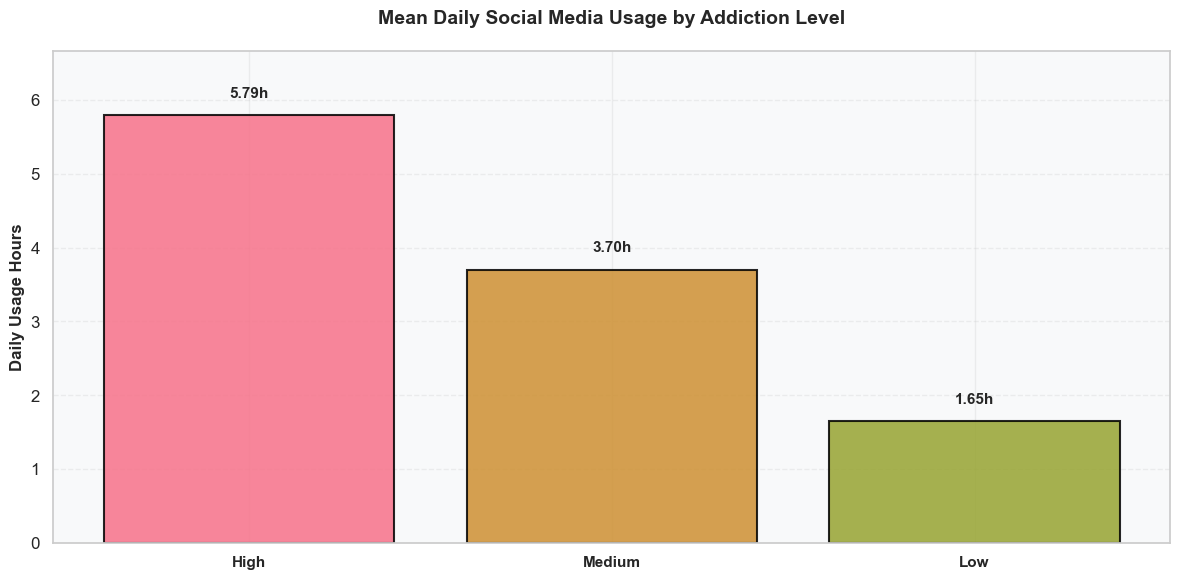

In [14]:
# ── Figure 1: Mean Daily Usage by Addiction Level (Bar Chart) ──────────────
print('\n📈 Generating Figure 1: Mean Daily Usage by Addiction Level')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data
    mean_data = summary_stats['Mean'].sort_values(ascending=False)
    
    # Create bar chart with gradient colors
    bars = ax.bar(range(len(mean_data)), mean_data.values, color=COLORS[:len(mean_data)], 
                  edgecolor='black', linewidth=1.5, alpha=0.85)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, mean_data.values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{value:.2f}h', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Customize chart
    ax.set_xticks(range(len(mean_data)))
    ax.set_xticklabels(mean_data.index, fontsize=11, fontweight='bold')
    ax.set_ylabel('Daily Usage Hours', fontsize=12, fontweight='bold')
    ax.set_title('Mean Daily Social Media Usage by Addiction Level', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylim(0, mean_data.max() * 1.15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_1_Mean_Usage_Bar.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 1 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 1: {e}')


📈 Generating Figure 2: Distribution Box Plot
✅ Figure 2 saved to: C:\Users\patil\Downloads\output\Fig_2_Distribution_Box.png


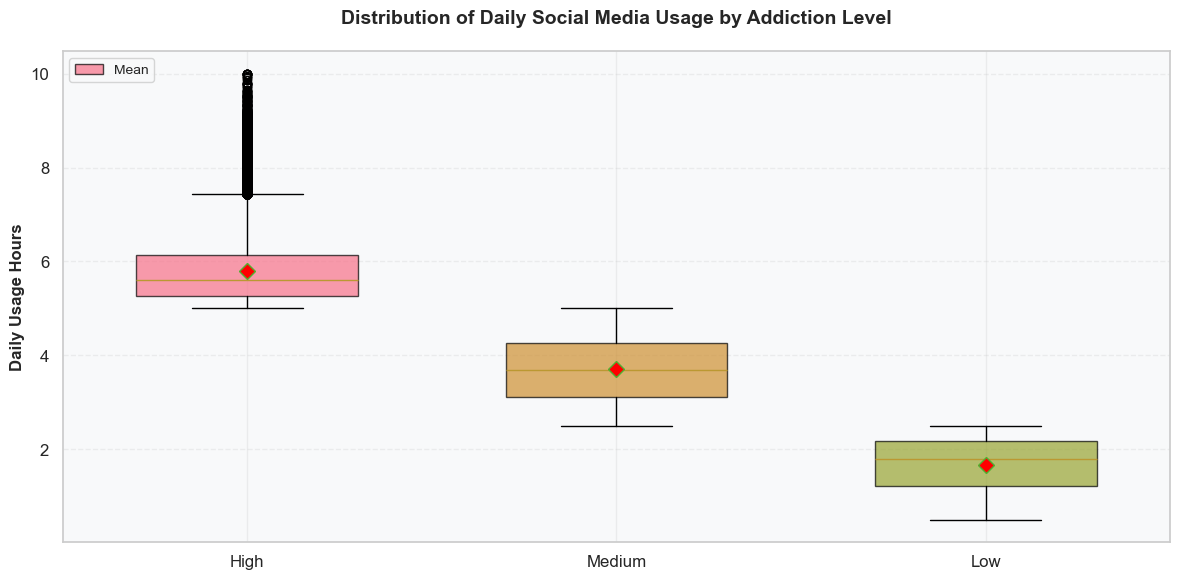

In [15]:
# ── Figure 2: Distribution of Daily Usage by Addiction Level (Box Plot) ────
print('\n📈 Generating Figure 2: Distribution Box Plot')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort by median for better visualization
    addiction_order = df.groupby('addiction_level')['daily_usage_hours'].median().sort_values(ascending=False).index
    
    # Create box plot
    bp = ax.boxplot([df[df['addiction_level'] == level]['daily_usage_hours'].values 
                      for level in addiction_order],
                     labels=addiction_order,
                     patch_artist=True,
                     widths=0.6,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8, label='Mean'))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], COLORS[:len(addiction_order)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Customize
    ax.set_ylabel('Daily Usage Hours', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Daily Social Media Usage by Addiction Level', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(['Mean'], loc='upper left', fontsize=10)
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_2_Distribution_Box.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 2 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 2: {e}')


📈 Generating Figure 3: User Distribution Pie Chart
✅ Figure 3 saved to: C:\Users\patil\Downloads\output\Fig_3_Distribution_Pie.png


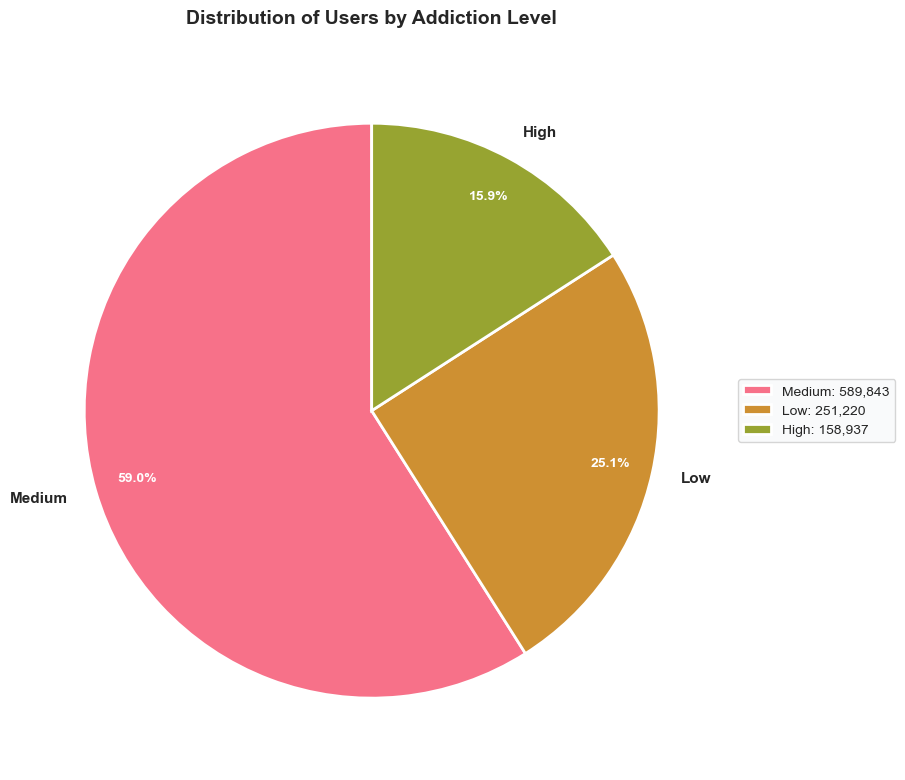

In [16]:
# ── Figure 3: User Distribution by Addiction Level (Pie Chart) ─────────────
print('\n📈 Generating Figure 3: User Distribution Pie Chart')

try:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Prepare data
    addiction_counts = df['addiction_level'].value_counts()
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        addiction_counts.values,
        labels=addiction_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=COLORS[:len(addiction_counts)],
        wedgeprops=dict(edgecolor='white', linewidth=2),
        pctdistance=0.85,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    # Customize percentage text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
    
    # Add count in legend
    legend_labels = [f'{label}: {count:,}' for label, count in addiction_counts.items()]
    ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
    
    ax.set_title('Distribution of Users by Addiction Level', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_3_Distribution_Pie.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 3 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 3: {e}')


📈 Generating Figure 4: Violin Plot Comparison
✅ Figure 4 saved to: C:\Users\patil\Downloads\output\Fig_4_Violin_Distribution.png


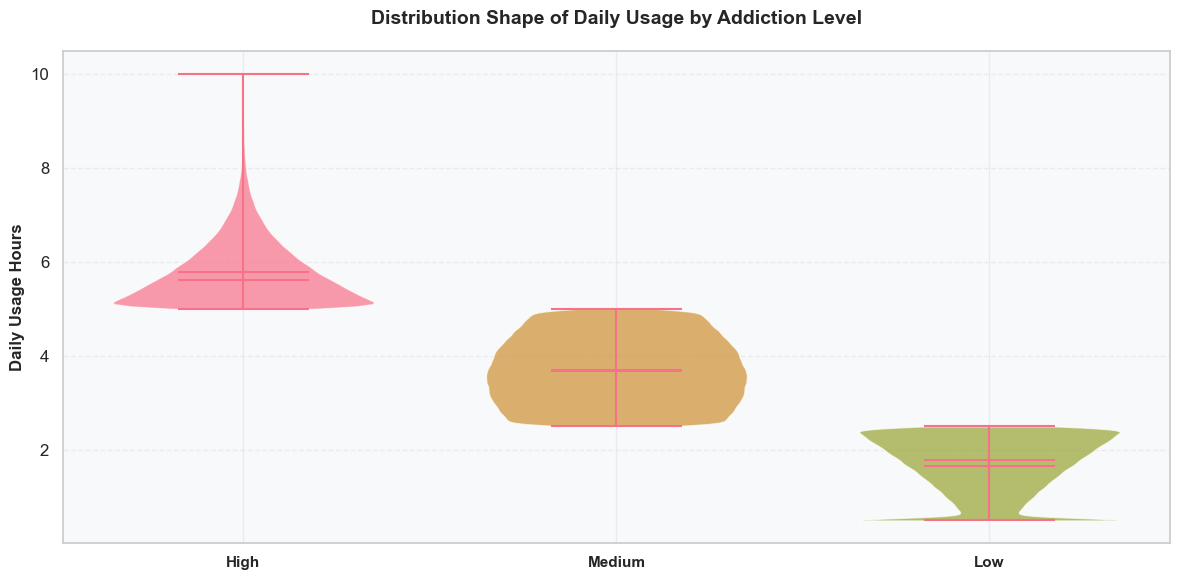

In [17]:
# ── Figure 4: Violin Plot (Distribution Comparison) ────────────────────────
print('\n📈 Generating Figure 4: Violin Plot Comparison')

try:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data for violin plot
    addiction_order = df.groupby('addiction_level')['daily_usage_hours'].median().sort_values(ascending=False).index
    plot_data = df[['addiction_level', 'daily_usage_hours']].copy()
    plot_data['addiction_level'] = pd.Categorical(plot_data['addiction_level'], categories=addiction_order, ordered=True)
    plot_data = plot_data.sort_values('addiction_level')
    
    # Create violin plot
    parts = ax.violinplot([df[df['addiction_level'] == level]['daily_usage_hours'].values 
                           for level in addiction_order],
                          positions=range(len(addiction_order)),
                          widths=0.7,
                          showmeans=True,
                          showmedians=True)
    
    # Color violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS[i])
        pc.set_alpha(0.7)
    
    # Customize
    ax.set_xticks(range(len(addiction_order)))
    ax.set_xticklabels(addiction_order, fontsize=11, fontweight='bold')
    ax.set_ylabel('Daily Usage Hours', fontsize=12, fontweight='bold')
    ax.set_title('Distribution Shape of Daily Usage by Addiction Level', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    fig_file = OUTPUT_DIR / 'Fig_4_Violin_Distribution.png'
    fig.savefig(fig_file, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✅ Figure 4 saved to: {fig_file}')
    plt.show()
    
except Exception as e:
    print(f'❌ Error generating Figure 4: {e}')

In [18]:
# ── Additional Statistics Table ───────────────────────────────────────────
print('\n📋 TABLE 2: Additional Statistical Measures')
print('=' * 70)

# Calculate skewness and kurtosis
from scipy import stats

additional_stats = []
for level in df['addiction_level'].unique():
    data = df[df['addiction_level'] == level]['daily_usage_hours']
    additional_stats.append({
        'Addiction Level': level,
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data),
        'Variance': data.var(),
        'IQR': data.quantile(0.75) - data.quantile(0.25)
    })

additional_df = pd.DataFrame(additional_stats).set_index('Addiction Level').round(4)
print('\n' + additional_df.to_string())
print('\n' + '-' * 70)

# Save additional stats
stats_file = OUTPUT_DIR / 'RQ1_Additional_Statistics.csv'
additional_df.to_csv(stats_file)
print(f'\n✅ Additional statistics saved to: {stats_file}')


📋 TABLE 2: Additional Statistical Measures

                 Skewness  Kurtosis  Variance     IQR
Addiction Level                                      
Medium             0.0849   -1.0901    0.4723  1.1403
High               1.3177    1.9905    0.4491  0.8655
Low               -0.5239   -0.9146    0.3813  0.9745

----------------------------------------------------------------------

✅ Additional statistics saved to: C:\Users\patil\Downloads\output\RQ1_Additional_Statistics.csv


In [19]:
# ── Final Summary Report ──────────────────────────────────────────────────
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - SUMMARY REPORT')
print('='*70)

print(f'\n📊 Key Findings:')
print('-' * 70)

# Find highest and lowest mean usage
highest_level = summary_stats['Mean'].idxmax()
lowest_level = summary_stats['Mean'].idxmin()
highest_mean = summary_stats['Mean'].max()
lowest_mean = summary_stats['Mean'].min()

print(f'\n✓ Highest mean usage: {highest_level} ({highest_mean:.2f} hours/day)')
print(f'✓ Lowest mean usage: {lowest_level} ({lowest_mean:.2f} hours/day)')
print(f'✓ Difference: {highest_mean - lowest_mean:.2f} hours/day')

print(f'\n📈 Distribution:')
for level in df['addiction_level'].unique():
    count = summary_stats.loc[level, 'Count']
    pct = summary_stats.loc[level, 'Percentage']
    print(f'   • {level}: {int(count):,} users ({pct:.1f}%)')

print(f'\n📁 Output Files Generated:')
print('-' * 70)
print(f'   Tables:')
print(f'   • RQ1_Summary_Table.csv')
print(f'   • RQ1_Additional_Statistics.csv')
print(f'\n   Figures:')
print(f'   • Fig_1_Mean_Usage_Bar.png')
print(f'   • Fig_2_Distribution_Box.png')
print(f'   • Fig_3_Distribution_Pie.png')
print(f'   • Fig_4_Violin_Distribution.png')
print(f'\n📂 All outputs saved to: {OUTPUT_DIR}')
print(f'\n' + '='*70)


✅ ANALYSIS COMPLETE - SUMMARY REPORT

📊 Key Findings:
----------------------------------------------------------------------

✓ Highest mean usage: High (5.79 hours/day)
✓ Lowest mean usage: Low (1.65 hours/day)
✓ Difference: 4.14 hours/day

📈 Distribution:
   • Medium: 589,843 users (59.0%)
   • High: 158,937 users (15.9%)
   • Low: 251,220 users (25.1%)

📁 Output Files Generated:
----------------------------------------------------------------------
   Tables:
   • RQ1_Summary_Table.csv
   • RQ1_Additional_Statistics.csv

   Figures:
   • Fig_1_Mean_Usage_Bar.png
   • Fig_2_Distribution_Box.png
   • Fig_3_Distribution_Pie.png
   • Fig_4_Violin_Distribution.png

📂 All outputs saved to: C:\Users\patil\Downloads\output

